# Get resulte on tng and flamingo

In [1]:
%load_ext autoreload
%autoreload 2

Loop through each filter and all the models and determine the threshold values for each

In [2]:
from get_model_probabilities import *
from add_shear_to_data import *
import scienceplots
plt.style.use(["science","grid"])

Source redshift:1.36


In [ ]:
imonte=10

#target_test_acc = pkl.load(open("pickles/target_test_accuracy.pkl","rb"))

ifilter='concat'
all_models =  glob(f"../models/concat/cdan_baha2dark_pre_squeezenet1_aw_1_pad_shear_avgpool_gauss_seed_*_nob1_ft_tweaked_align_10_best.pth")


output_name = f"pickles/flamingo_tng_results.pkl"


all_results = pkl.load(open(output_name,'rb'))

for imodel in tqdm(all_models):

    seed = imodel.split('_')[-7]




    args.jwst_filter = ifilter
    args.apply_intrinsic_ell = 1.
    args.verbose=False
    zs = {
    'f115w':1.6,
    'f150w':1.65,
    'concat':1.65
    }

    domain = {
    'tgt':'flamingo_obs',
    'src':'tng_obs'
    }
    args.ignore_dataset = [''] # Although i ignored during training i want to see duringn testing.

    if f"seed_{seed}" not in all_results.keys():

        all_results[f"seed_{seed}"]  = {'src':[],'tgt':[]}

    args.unbalance = True
    
    for i in range(imonte):
        args.zs = zs[ifilter]

        for idomain in domain.keys():

            target_domain = domain[idomain]
            results = get_probabilities( 
                    target_domain,
                    [imodel],
                    args,
                    quiet=True
            )
            del results['data_loaders']

            all_results[f"seed_{seed}"][idomain].append( results )

    pkl.dump(all_results, open(output_name,"wb"))


  0%|                                                       | 0/30 [00:00<?, ?it/s]

ERROR! Session/line number was not unique in database. History logging moved to new session 2081


 17%|███████▊                                       | 5/30 [03:18<16:29, 39.59s/it]

[0.6010047928695907, 0.5578445060844193]
[0.6225849362621765, 0.5362643626918335]
[0.6010047928695907, 0.5578445060844193]
[0.6225849362621765, 0.5362643626918335]


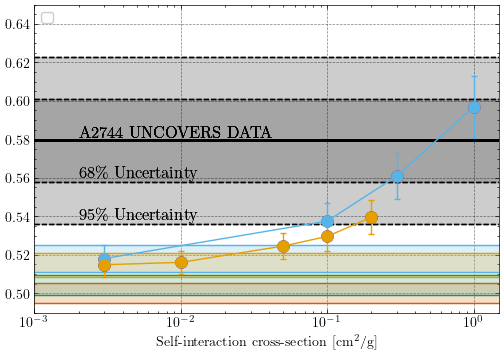

In [5]:
config='baha2dark'

ifilter  = 'concat'
cdm = 3e-3

color = {
        'src':'r',
        'tgt':'b'
    }

this_domain = [ {
    'tgt':'flamingo_obs',
    'src':'tng_obs'
    },
    {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
    }]


model = f"pickles/{config}_basemodel_results.pkl"

all_results = pkl.load(open(model,'rb'))

correction = 2.
### MASS WEIGHTS FOR CALCULATING THE MEAN #####
zs = 1.65
zl = 0.305
critical_density = sigma_critical(zl, zs, Planck18).to(units.Msun/units.kpc/units.kpc)

bah_meta, bah_data = pkl.load(open("../data/shear/tng.pkl","rb"))
dar_meta, dar_data = pkl.load(open("../data/shear/flamingo.pkl","rb"))
mass_bah = np.log10(np.sum(np.sum(bah_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)
mass_dark = np.log10(np.sum(np.sum(dar_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)

yb, x = np.histogram(mass_bah, bins=np.linspace(14,15.5,30))
yb[ yb == 0] = 1
yd, x = np.histogram(mass_dark, bins=np.linspace(14,15.5,30))
yd[yd==0] = 1
mass_weights = {'src':{'x':x, 'y':1./yb},'tgt':{'x':x, 'y':1./yd}} 
#######


fig = plt.figure(figsize=(6,4))

ax = plt.gca()


fiducial = f"pickles/all_models_{ifilter}_zs_results.pkl"
tng_flamingo = f"pickles/flamingo_tng_results.pkl"

colors = {
    'flamingo':'cyan', 'bahamas':'r', 'darkskies':'b','tng':'k'}
for ifx, results_file in enumerate( [tng_flamingo, fiducial]):
    domain = this_domain[ifx]
    

    all_results = pkl.load(open(results_file,'rb'))

    postive_mass, mass_cut = get_mass_cut( ifilter, nsigma=1., study='harvey' )
    
    
    mass_cut = [ i for i in mass_cut]
    
    ref = None
    for itgt, target in enumerate(['src','tgt']):
        all_thresholds = []
        for imodel in all_results.keys():
            
            seed = float(imodel.split('_')[1])                
            

            tgt = get_threshold_for_cross( 
                all_results[imodel][target], 
                mass_cut=None, 
                integrated_mass=True,
                function=np.mean,
                mass_weights=None, #mass_weights[target],
                dataset=domain[target].split('_')[0],
                quiet=False)

            
            all_thresholds.append(tgt['thresholds'])
            
        all_thresholds = np.array(all_thresholds)
        means = np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction
        
        if ref is None:
            ref = means.copy()
            
        if tgt['cross_sections'].shape[0] > 1:
            tgt['cross_sections'][0] += cdm
            ax.errorbar( tgt['cross_sections'], 
                   1-means,
                    errors,
                    fmt='-o', 
                    capsize=2,
                    markersize=8, color=colour_scheme[domain[target].split('_')[0].lower()])
            ax.plot( tgt['cross_sections'], 
                   1-means,
                    'o', 
                    markersize=8, color=color[target])
        
        # ax.plot( np.logspace(-3,1,100),
        #                 np.zeros(100)+(1-means[0]), '--',lw=2, 
        #                 label=domain[target].split('_')[0].upper(),
        #                  color=colour_scheme[f"{domain[target].split('_')[0].lower()}"])
        
        ax.plot( np.logspace(-3,1,100),
                        np.zeros(100)+(1-means[0])+errors[0], '-',lw=1, 
                         color=colour_scheme[f"{domain[target].split('_')[0].lower()}"])
        ax.plot( np.logspace(-3,1,100),
                        np.zeros(100)+(1-means[0])-errors[0], '-',lw=1, 
                         color=colour_scheme[f"{domain[target].split('_')[0].lower()}"])
        ax.fill_between( np.logspace(-3,1,100),
                        np.zeros(100)+(1-means[0])+errors[0],
                        np.zeros(100)+(1-means[0])-errors[0],
                         color=colour_scheme[f"{domain[target].split('_')[0].lower()}"],
                       alpha=0.2)
        
        
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
        ax.legend(ncols=2,loc=2)
    ax.set_xscale('log')

    ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
    #ax.set_ylabel("Model threshold output")

    #
    ax.set_xlim(1e-3,1.5)
    
    ax.set_xscale('log')


    plot_observations( "pickles/model_on_data.pkl", ifilter, ax=ax, correction=correction, 
                      plot_args={'lw':2, 'color':'k'}, fill_args={'alpha':0.1, 'color':'k'},
                      uncertainty=[68,95])
    #plot_observations( "pickles/model_on_data.pkl", ifilter, ax=ax, noise=True, legend=False, **{'label':'Noise','color':'k'} )
    ax.legend(loc=2)
    ax.set_ylim(0.49,0.65)



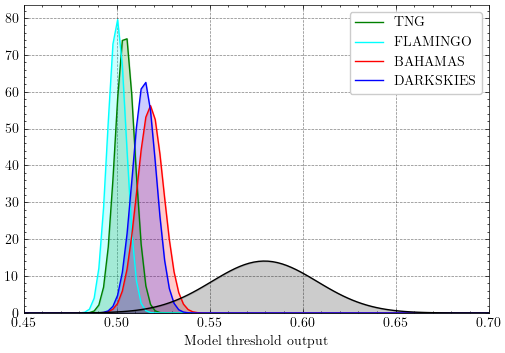

In [12]:
config='baha2dark'

ifilter  = 'concat'
cdm = 3e-3

color = {
        'src':'r',
        'tgt':'b'
    }




model = f"pickles/{config}_basemodel_results.pkl"

all_results = pkl.load(open(model,'rb'))

correction = 2.
### MASS WEIGHTS FOR CALCULATING THE MEAN #####
zs = 1.65
zl = 0.305
critical_density = sigma_critical(zl, zs, Planck18).to(units.Msun/units.kpc/units.kpc)

bah_meta, bah_data = pkl.load(open("../data/shear/tng.pkl","rb"))
dar_meta, dar_data = pkl.load(open("../data/shear/flamingo.pkl","rb"))
mass_bah = np.log10(np.sum(np.sum(bah_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)
mass_dark = np.log10(np.sum(np.sum(dar_data[:,2],axis=-1)*critical_density* (20*units.kpc)**2, axis=-1).value)

yb, x = np.histogram(mass_bah, bins=np.linspace(14,15.5,30))
yb[ yb == 0] = 1
yd, x = np.histogram(mass_dark, bins=np.linspace(14,15.5,30))
yd[yd==0] = 1
mass_weights = {'src':{'x':x, 'y':1./yb},'tgt':{'x':x, 'y':1./yd}} 
#######


fig = plt.figure(figsize=(6,4))

ax = plt.gca()


this_domain = [ {
    'tgt':'flamingo_obs',
    'src':'tng_obs'
    },
    {
    'tgt':'darkskies_obs',
    'src':'bahamas_obs'
    }]
fiducial = f"pickles/all_models_{ifilter}_zs_results.pkl"
tng_flamingo = f"pickles/flamingo_tng_results.pkl"

colors = {
    'flamingo':'cyan', 'bahamas':'r', 'darkskies':'b','tng':'green'}
for ifx, results_file in enumerate( [tng_flamingo, fiducial]):
    domain = this_domain[ifx]
    

    all_results = pkl.load(open(results_file,'rb'))

    postive_mass, mass_cut = get_mass_cut( ifilter, nsigma=1., study='harvey' )
    
    
    mass_cut = [ i for i in mass_cut]
    
    ref = None
    for itgt, target in enumerate(['src','tgt']):
        all_thresholds = []
        for imodel in all_results.keys():
            
            seed = float(imodel.split('_')[1])                
            

            tgt = get_threshold_for_cross( 
                all_results[imodel][target], 
                mass_cut=None, 
                integrated_mass=True,
                function=np.mean,
                mass_weights=None, #mass_weights[target],
                dataset=domain[target].split('_')[0],
                quiet=False)

            
            all_thresholds.append(tgt['thresholds'])
            
        all_thresholds = np.array(all_thresholds)
        means = np.nanmean(all_thresholds,axis=0)
        errors = np.std(all_thresholds,axis=0) / all_thresholds.shape[0]**0.38*correction
        
        if ref is None:
            ref = means.copy()
            
        
        xpdf = np.linspace(0.45,0.7, 100)
        
        ypdf = norm.pdf( xpdf, *(1-means[0], errors[0]))
        
        ax.plot(  xpdf, ypdf,
                        label=domain[target].split('_')[0].upper(),
                         color=colors[f"{domain[target].split('_')[0].lower()}"])
        
        ax.fill_between( xpdf,
                        ypdf,
                        np.zeros(100),
                         color=colors[f"{domain[target].split('_')[0].lower()}"],
                       alpha=0.2)
        
        
        ax.set_xlabel("Self-interaction cross-section [cm$^2$/g]")
        ax.legend(ncols=2,loc=2)

    ax.set_xlabel("Model threshold output")




    ax.legend(loc=1)
    ax.set_ylim(0,ax.get_ylim()[1])
    ax.set_xlim(xpdf.min(), xpdf.max())
    
models, probabilities, probabilities_noise = pkl.load(open("pickles/model_on_data.pkl",'rb'))
data = probabilities[ifilter]
nmodels = data.shape[0]



means = 1-np.mean(data)
correction = 2.0
error = np.std(data)/nmodels**(0.3)*correction

ypdf = norm.pdf( xpdf, *(means, error))

ax.plot(  xpdf, ypdf,
                    label='A2744 UNCOVER',
                     color='k')

ax.fill_between( xpdf,
                    ypdf,
                    np.zeros(100),
                     color='k',
                   alpha=0.2)  
